# PSet 2 - Problem 2 (DMP)

This notebook is self-contained and implements the iterative, Broyden, and exact-Newton solution methods directly in notebook cells.

It relies on `hetmacro` for:
- Rouwenhorst discretization (`hetmacro.markov.rouwenhorst`)
- Broyden solver (`hetmacro.optimize.broyden`)

The Dynare perturbation part remains in MATLAB (`benchmark.mod`).

In [7]:
import sys
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent
TEX_DIR = ROOT / "tex"
TEX_DIR.mkdir(exist_ok=True)

# Robust repo-root detection from current working directory.
HET_REPO = None
for p in [ROOT, *ROOT.parents]:
    if (p / "hetmacro").exists():
        HET_REPO = p
        break
if HET_REPO is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(HET_REPO) not in sys.path:
    sys.path.append(str(HET_REPO))

from hetmacro.markov import rouwenhorst
from hetmacro.optimize import broyden

print("ROOT:", ROOT)
print("HET_REPO:", HET_REPO)

ROOT: /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions
HET_REPO exists: True


In [2]:
@dataclass
class DMPModel:
    beta: float = 0.96 ** (1 / 12)
    sigma: float = 0.04
    gamma: float = 0.50
    b: float = 0.7
    rhoz: float = 0.90 ** (1 / 12)
    sz: float = 0.005
    alpha: float = 0.50
    B: float = 0.40
    nz: int = 51

    def steady_state_objects(self) -> tuple[float, float]:
        """Steady-state surplus and vacancy cost at theta=1, lambda_w=B."""
        lambdaw_ss = self.B
        z_ss = 1.0
        S_ss = (z_ss - self.b) / (1.0 - self.beta * (1.0 - self.sigma - self.gamma * lambdaw_ss))
        kappa = (1.0 - self.gamma) * self.B * (z_ss - self.b) / (
            1.0 / self.beta - 1.0 + self.sigma + self.gamma * lambdaw_ss
        )
        return S_ss, kappa

    def build_grids(self) -> tuple[np.ndarray, np.ndarray]:
        zlog, Pi = rouwenhorst(self.nz, self.rhoz, self.sz)
        return np.exp(zlog), Pi

    def update_lambda(self, S: np.ndarray, Pi: np.ndarray, kappa: float) -> np.ndarray:
        ES = self.beta * (Pi @ S)
        c = (self.B ** (1.0 / self.alpha)) * (((1.0 - self.gamma) / kappa) ** ((1.0 - self.alpha) / self.alpha))
        return c * (ES ** ((1.0 - self.alpha) / self.alpha))


@dataclass
class DMPModelSolution:
    model: DMPModel
    z: np.ndarray
    Pi: np.ndarray
    kappa: float

    def residual_and_jacobian(self, x: np.ndarray):
        nz = self.model.nz
        S = x[:nz]
        lamb = x[nz:]
        PS = self.Pi @ S
        ES = self.model.beta * PS

        y1 = S - (self.z - self.model.b + self.model.beta * (1.0 - self.model.sigma - self.model.gamma * lamb) * PS)
        c = (self.model.B ** (1.0 / self.model.alpha)) * (
            ((1.0 - self.model.gamma) / self.kappa) ** ((1.0 - self.model.alpha) / self.model.alpha)
        )
        q = (1.0 - self.model.alpha) / self.model.alpha
        y2 = lamb - c * (ES**q)
        y = np.concatenate([y1, y2])

        J = np.zeros((2 * nz, 2 * nz))
        J[:nz, :nz] = np.eye(nz) - self.model.beta * (
            (1.0 - self.model.sigma - self.model.gamma * lamb)[:, None] * self.Pi
        )
        J[:nz, nz:] = np.diag(self.model.beta * self.model.gamma * PS)

        dterm_dS = c * q * (ES ** (q - 1.0))[:, None] * (self.model.beta * self.Pi)
        J[nz:, :nz] = -dterm_dS
        J[nz:, nz:] = np.eye(nz)
        return y, J

    def residual_only(self, x: np.ndarray) -> np.ndarray:
        y, _ = self.residual_and_jacobian(x)
        return y

    def solve_iterative(self, tol: float = 1e-11, max_iter: int = 200):
        lamb = np.full(self.model.nz, self.model.B)
        I = np.eye(self.model.nz)
        for it in range(max_iter):
            lamb_old = lamb.copy()
            A = I - self.model.beta * ((1.0 - self.model.sigma - self.model.gamma * lamb)[:, None] * self.Pi)
            S = np.linalg.solve(A, self.z - self.model.b)
            lamb = self.model.update_lambda(S, self.Pi, self.kappa)
            if np.linalg.norm(lamb - lamb_old, ord=np.inf) < tol:
                break
        return S, lamb, it + 1

    def solve_newton_broyden(self, tol: float = 1e-11, max_iter: int = 200):
        S_ss, _ = self.model.steady_state_objects()
        x0 = np.concatenate([np.full(self.model.nz, S_ss), np.full(self.model.nz, self.model.B)])
        x, fval, flag, it, _ = broyden(
            self.residual_only,
            x0,
            method="compecon",
            tol=tol,
            max_iter=max_iter,
        )
        S = x[: self.model.nz]
        lamb = x[self.model.nz :]
        return S, lamb, np.linalg.norm(fval, ord=np.inf), flag, it

    def solve_newton_exact(self, tol: float = 1e-11, max_iter: int = 200):
        S_ss, _ = self.model.steady_state_objects()
        x = np.concatenate([np.full(self.model.nz, S_ss), np.full(self.model.nz, self.model.B)])
        for it in range(1, max_iter + 1):
            y, J = self.residual_and_jacobian(x)
            dx = np.linalg.solve(J, y)
            x_new = x - dx
            if np.linalg.norm(y, ord=np.inf) < tol and np.linalg.norm(x_new - x, ord=np.inf) < tol:
                x = x_new
                break
            x = x_new
        S = x[: self.model.nz]
        lamb = x[self.model.nz :]
        return S, lamb, it


In [3]:
model = DMPModel()
S_ss, kappa = model.steady_state_objects()
z, Pi = model.build_grids()
solver = DMPModelSolution(model=model, z=z, Pi=Pi, kappa=kappa)

S_it, lw_it, it_it = solver.solve_iterative()
S_br, lw_br, fnorm, flag, it_br = solver.solve_newton_broyden()
S_nw, lw_nw, it_nw = solver.solve_newton_exact()

summary = pd.DataFrame([
    {"method": "iterative", "iterations": it_it, "max_S": float(S_it.max()), "max_lambda": float(lw_it.max())},
    {"method": "broyden", "iterations": it_br, "max_S": float(S_br.max()), "max_lambda": float(lw_br.max()), "fnorm": fnorm, "flag": flag},
    {"method": "newton_exact", "iterations": it_nw, "max_S": float(S_nw.max()), "max_lambda": float(lw_nw.max())},
])

summary

,method,iterations,max_S,max_lambda,fnorm,flag
0,iterative,125,1.808681,0.583424,NaN,NaN
1,broyden,15,1.808681,0.583424,4.440892e-16,0.0
2,newton_exact,6,1.808681,0.583424,NaN,NaN


Saved summary/profile tables and figure to /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions/tex


,method,iterations,max_S,max_lambda,fnorm,flag
0,iterative,125,1.808681,0.583424,NaN,NaN
1,broyden,15,1.808681,0.583424,4.440892e-16,0.0
2,newton_exact,6,1.808681,0.583424,NaN,NaN


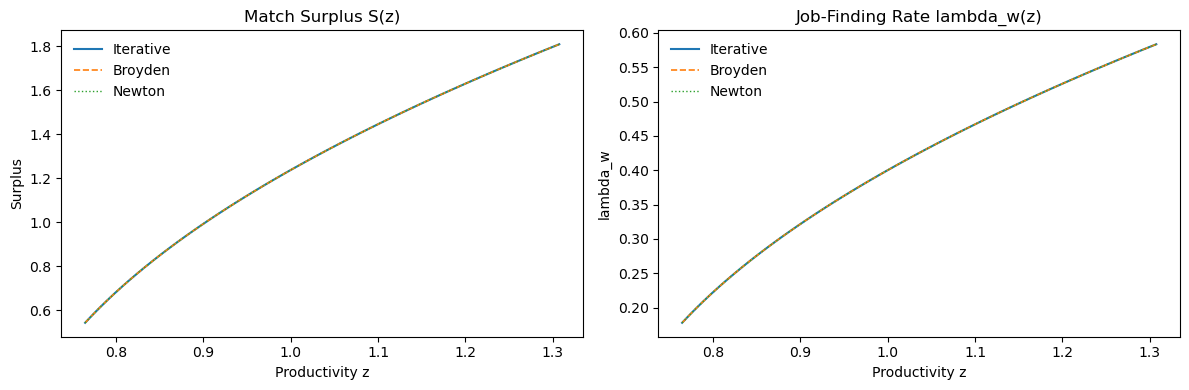

In [4]:
summary.to_csv(TEX_DIR / "problem2_summary.csv", index=False)
pd.DataFrame(
    {
        "z": z,
        "S_iter": S_it,
        "S_broyden": S_br,
        "S_newton": S_nw,
        "lambda_iter": lw_it,
        "lambda_broyden": lw_br,
        "lambda_newton": lw_nw,
    }
).to_csv(TEX_DIR / "problem2_profiles.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

axes[0].plot(z, S_it, lw=1.5, label="Iterative")
axes[0].plot(z, S_br, lw=1.2, ls="--", label="Broyden")
axes[0].plot(z, S_nw, lw=1.0, ls=":", label="Newton")
axes[0].set_title("Match Surplus S(z)")
axes[0].set_xlabel("Productivity z")
axes[0].set_ylabel("Surplus")
axes[0].legend(frameon=False)

axes[1].plot(z, lw_it, lw=1.5, label="Iterative")
axes[1].plot(z, lw_br, lw=1.2, ls="--", label="Broyden")
axes[1].plot(z, lw_nw, lw=1.0, ls=":", label="Newton")
axes[1].set_title("Job-Finding Rate lambda_w(z)")
axes[1].set_xlabel("Productivity z")
axes[1].set_ylabel("lambda_w")
axes[1].legend(frameon=False)

fig.savefig(TEX_DIR / "fig_problem2_profiles.pdf", bbox_inches="tight")
fig.savefig(TEX_DIR / "fig_problem2_profiles.png", dpi=200, bbox_inches="tight")

print("Saved summary/profile tables and figure to", TEX_DIR)
summary

Dynare results: /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions/benchmark_reduced/Output/benchmark_reduced_results.mat
Dynare (impact) coefficients:
  dS/dlog z       = 2.2306736965722007
  dλ_w/dlog z     = 0.715198633161396
Nonlinear numerical slope at z≈1 (central diff):
  dS/dlog z       = 2.238577422662187
  dλ_w/dlog z     = 0.7177507649017908
Saved comparison figure to /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions/tex


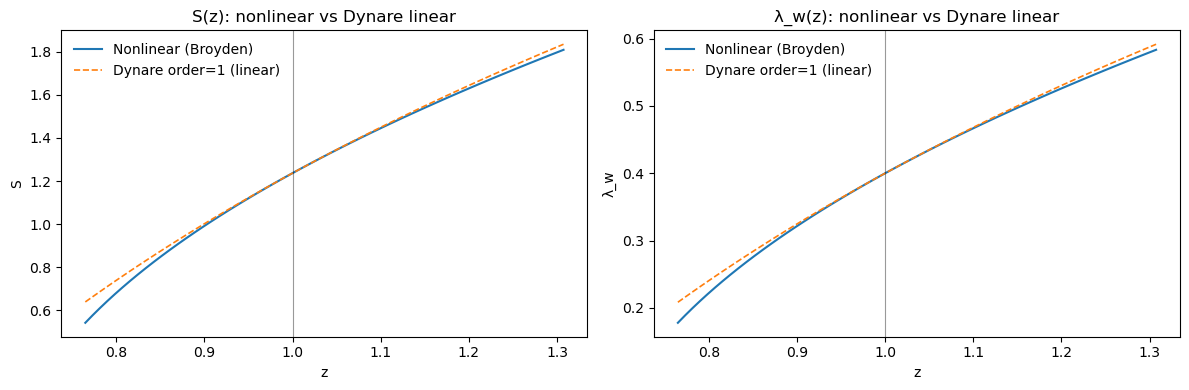

In [8]:
# --- Dynare order=1 import + comparison ---------------------------------
# Run Dynare first (MATLAB): benchmark_reduced.mod (or benchmark.mod).
# Dynare creates a file like: <model_name>_results.mat in the folder where you ran Dynare.

# Dynare writes to the folder where you run it (ROOT = "My Code and Solutions").
# Newer Dynare puts results in <model>/Output/<model>_results.mat; older versions use <model>_results.mat in cwd.
DYNARE_DIR = ROOT
MODEL_NAME = "benchmark_reduced"  # change to "benchmark" if that's what you ran

# Try (1) project root, then (2) Dynare's <model>/Output/ subfolder
RESULTS_MAT = DYNARE_DIR / f"{MODEL_NAME}_results.mat"
if not RESULTS_MAT.exists():
    results_in_output = DYNARE_DIR / MODEL_NAME / "Output" / f"{MODEL_NAME}_results.mat"
    if results_in_output.exists():
        RESULTS_MAT = results_in_output
    else:
        # Fallback: any *_results.mat in ROOT or in ROOT/*/Output/
        candidates = list(DYNARE_DIR.glob("*_results.mat")) + list(DYNARE_DIR.glob("*/Output/*_results.mat"))
        candidates = sorted(set(candidates))
        if len(candidates) == 1:
            RESULTS_MAT = candidates[0]
        elif len(candidates) > 1:
            print("Multiple *_results.mat found. Set MODEL_NAME or pick one. Candidates:")
            for p in candidates:
                print(" -", p)
            raise FileNotFoundError("Set RESULTS_MAT to one of the paths above.")
        else:
            raise FileNotFoundError(
                f"No Dynare *_results.mat found under {DYNARE_DIR}. "
                "Run Dynare from this folder in MATLAB: cd('<ROOT>'); dynare benchmark_reduced"
            )

print("Dynare results:", RESULTS_MAT)


def _dynare_get_irf(oo_irfs, var: str, shock: str) -> np.ndarray:
    name = f"{var}_{shock}"
    if not hasattr(oo_irfs, name):
        raise KeyError(
            f"IRF '{name}' not found. Available fields: {sorted([k for k in dir(oo_irfs) if '_' in k])[:20]} ..."
        )
    arr = getattr(oo_irfs, name)
    return np.asarray(arr).squeeze()


def dynare_linear_coeffs_from_irfs(results_mat_path: Path, shock: str = "e_z") -> dict:
    """Compute (impact) linear coefficients dS/dlogz and dlambdaw/dlogz from Dynare IRFs."""
    d = loadmat(results_mat_path, squeeze_me=True, struct_as_record=False)
    if "oo_" not in d:
        raise KeyError(f"'oo_' not found in {results_mat_path.name}. Keys: {sorted(d.keys())}")
    oo = d["oo_"]
    if not hasattr(oo, "irfs"):
        raise KeyError("oo_.irfs not found. Make sure you ran stoch_simul(order=1 or 2).")

    irf_S = _dynare_get_irf(oo.irfs, "S", shock)
    irf_lw = _dynare_get_irf(oo.irfs, "lambdaw", shock)
    irf_z = _dynare_get_irf(oo.irfs, "z", shock)

    z_ss = 1.0
    dlogz0 = float(np.log(z_ss + irf_z[0]) - np.log(z_ss))
    if abs(dlogz0) < 1e-14:
        raise ValueError("Impact response of z is ~0; can't infer coefficients from IRFs.")

    phi_S = float(irf_S[0] / dlogz0)
    phi_lw = float(irf_lw[0] / dlogz0)

    return {
        "phi_S": phi_S,
        "phi_lambdaw": phi_lw,
        "irf_S": irf_S,
        "irf_lambdaw": irf_lw,
        "irf_z": irf_z,
        "dlogz0": dlogz0,
    }


dyn = dynare_linear_coeffs_from_irfs(RESULTS_MAT, shock="e_z")
print("Dynare (impact) coefficients:")
print("  dS/dlog z       =", dyn["phi_S"])
print("  dλ_w/dlog z     =", dyn["phi_lambdaw"])

# Build Dynare-implied linear policy curves around z=1
zhat_grid = np.log(z) - np.log(1.0)
S_dyn_lin = S_ss + dyn["phi_S"] * zhat_grid
lw_dyn_lin = model.B + dyn["phi_lambdaw"] * zhat_grid

# Also compute a local numerical slope from the nonlinear solution at z≈1
idx = int(np.argmin(np.abs(z - 1.0)))
idx = min(max(idx, 1), len(z) - 2)
dS_dlogz_num = float((S_br[idx + 1] - S_br[idx - 1]) / (np.log(z[idx + 1]) - np.log(z[idx - 1])))
dl_dlogz_num = float((lw_br[idx + 1] - lw_br[idx - 1]) / (np.log(z[idx + 1]) - np.log(z[idx - 1])))
print("Nonlinear numerical slope at z≈1 (central diff):")
print("  dS/dlog z       =", dS_dlogz_num)
print("  dλ_w/dlog z     =", dl_dlogz_num)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

axes[0].plot(z, S_br, lw=1.5, label="Nonlinear (Broyden)")
axes[0].plot(z, S_dyn_lin, lw=1.2, ls="--", label="Dynare order=1 (linear)")
axes[0].axvline(1.0, color="k", lw=0.8, alpha=0.4)
axes[0].set_title("S(z): nonlinear vs Dynare linear")
axes[0].set_xlabel("z")
axes[0].set_ylabel("S")
axes[0].legend(frameon=False)

axes[1].plot(z, lw_br, lw=1.5, label="Nonlinear (Broyden)")
axes[1].plot(z, lw_dyn_lin, lw=1.2, ls="--", label="Dynare order=1 (linear)")
axes[1].axvline(1.0, color="k", lw=0.8, alpha=0.4)
axes[1].set_title("λ_w(z): nonlinear vs Dynare linear")
axes[1].set_xlabel("z")
axes[1].set_ylabel("λ_w")
axes[1].legend(frameon=False)

fig.savefig(TEX_DIR / "fig_problem2_profiles_dynare_linear_compare.pdf", bbox_inches="tight")
fig.savefig(TEX_DIR / "fig_problem2_profiles_dynare_linear_compare.png", dpi=200, bbox_inches="tight")

print("Saved comparison figure to", TEX_DIR)

Saved simulation series and figure to /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions/tex
Mean productivity (recession threshold): 1.036


,mean,std,min,max
t,119.500000,69.426220,0.000000,239.000000
z,1.036045,0.017218,0.998163,1.070392
S,1.314709,0.036527,1.232532,1.386289
lambda_w,0.425009,0.011713,0.398658,0.447963
lambda_f,0.376748,0.010398,0.357172,0.401346
theta,1.129807,0.062230,0.993302,1.254194
unemployment,0.086106,0.002148,0.082283,0.091032
vacancy_rate,0.097159,0.003203,0.089816,0.104259


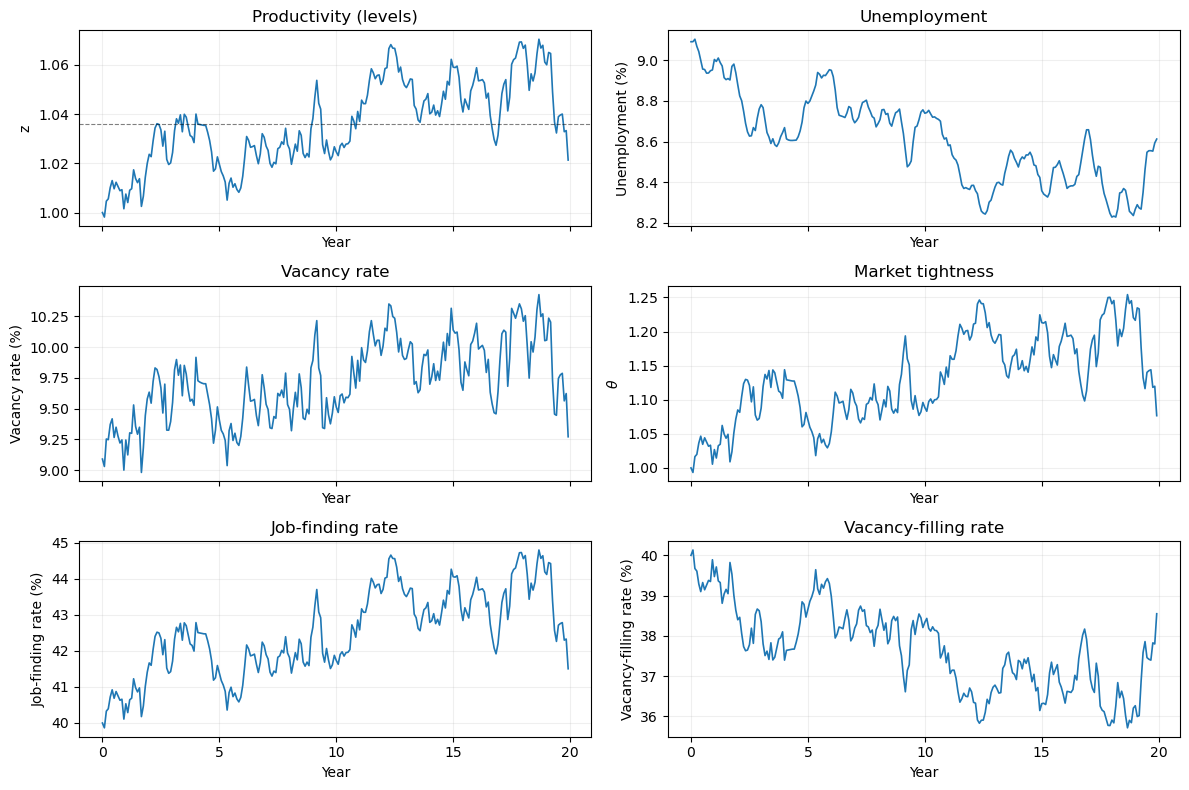

In [ ]:
# --- Simulated labor-market fluctuations under calibrated DMP ----------
rng = np.random.default_rng(123)
T = 240  # months

# Simulate productivity process: log z_{t+1} = rho_z log z_t + sz * eps_{t+1}
logz_sim = np.zeros(T)
eps = rng.standard_normal(T)
for t in range(1, T):
    logz_sim[t] = model.rhoz * logz_sim[t - 1] + model.sz * eps[t]
z_sim = np.exp(logz_sim)

# Map productivity into policy objects using the nonlinear solution (Broyden)
lw_sim = np.interp(z_sim, z, lw_br, left=lw_br[0], right=lw_br[-1])
S_sim = np.interp(z_sim, z, S_br, left=S_br[0], right=S_br[-1])

# Market tightness and vacancy-filling from matching identities
# lambda_w = B * theta^(1-alpha), lambda_f = B * theta^(-alpha)
theta_sim = (lw_sim / model.B) ** (1.0 / (1.0 - model.alpha))
lf_sim = model.B * theta_sim ** (-model.alpha)

# Unemployment dynamics: u_{t+1} = sigma*(1-u_t) + (1-lambda_w,t)*u_t
u_sim = np.empty(T)
u_ss = model.sigma / (model.sigma + model.B)  # at theta=1 => lambda_w_ss=B
u_sim[0] = u_ss
for t in range(T - 1):
    u_sim[t + 1] = model.sigma * (1.0 - u_sim[t]) + (1.0 - lw_sim[t]) * u_sim[t]

# Vacancy rate via v_t = theta_t * u_t (since theta = v/u)
v_sim = theta_sim * u_sim

sim_df = pd.DataFrame(
    {
        "t": np.arange(T),
        "z": z_sim,
        "S": S_sim,
        "lambda_w": lw_sim,
        "lambda_f": lf_sim,
        "theta": theta_sim,
        "unemployment": u_sim,
        "vacancy_rate": v_sim,
    }
)
sim_df.to_csv(TEX_DIR / "problem2_simulation_series.csv", index=False)

z_mean = float(z_sim.mean())

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, tight_layout=True)
t = sim_df["t"].to_numpy()
months_per_year = 12
years_ticks = np.arange(0, T + 1, 5 * months_per_year)
year_labels = np.arange(0, (T // months_per_year) + 1, 5)

for ax in axes.ravel():
    ax.set_xticks(years_ticks)
    ax.set_xticklabels(year_labels)
    ax.set_xlabel("Year")
    ax.grid(alpha=0.2)

# Productivity (levels)
axes[0, 0].plot(t, sim_df["z"], lw=1.2)
axes[0, 0].axhline(z_mean, color="k", ls="--", alpha=0.5, lw=0.8)
axes[0, 0].set_title("Productivity (levels)")
axes[0, 0].set_ylabel("z")

# Unemployment (%)
axes[0, 1].plot(t, sim_df["unemployment"] * 100, lw=1.2)
axes[0, 1].set_title("Unemployment")
axes[0, 1].set_ylabel("Unemployment (%)")

# Vacancy rate (%)
axes[1, 0].plot(t, sim_df["vacancy_rate"] * 100, lw=1.2)
axes[1, 0].set_title("Vacancy rate")
axes[1, 0].set_ylabel("Vacancy rate (%)")

# Market tightness (levels)
axes[1, 1].plot(t, sim_df["theta"], lw=1.2)
axes[1, 1].set_title("Market tightness")
axes[1, 1].set_ylabel(r"$\theta$")

# Job-finding rate (%)
axes[2, 0].plot(t, sim_df["lambda_w"] * 100, lw=1.2)
axes[2, 0].set_title("Job-finding rate")
axes[2, 0].set_ylabel("Job-finding rate (%)")
# Vacancy-filling rate (%)
axes[2, 1].plot(t, sim_df["lambda_f"] * 100, lw=1.2)
axes[2, 1].set_title("Vacancy-filling rate")
axes[2, 1].set_ylabel("Vacancy-filling rate (%)")

fig.savefig(TEX_DIR / "fig_problem2_simulated_labor_fluctuations.pdf", bbox_inches="tight")
fig.savefig(TEX_DIR / "fig_problem2_simulated_labor_fluctuations.png", dpi=200, bbox_inches="tight")

print("Saved simulation series and figure to", TEX_DIR)
print("Mean productivity (recession threshold):", round(z_mean, 4))
sim_df.describe().T[["mean", "std", "min", "max"]]